In [1]:
# ==============================================================================
# REFINED DYNAMO BYPASS (Run this at the absolute top of your notebook)
# ==============================================================================
import torch

class SmartDummyCompiler:
    class CallableFalse:
        def __call__(self, fn=None, *args, **kwargs):
            if fn is None:
                return self  # Handles parameterized decorators like @decorator(arg=True)
            return fn        # Handles standard decorators like @decorator
            
        def __bool__(self):
            return False     # Forces the object to evaluate as False in boolean expressions

    def __getattr__(self, name):
        return self.CallableFalse()

# Overwrite the compiler namespace completely
torch.compiler = SmartDummyCompiler()

# Integrated Gradients
## What are Integrated Gradients?
Gradient-based attribution techniques determine the importance of each input feature by analyzing the partial derivatives of the output with respect to each input dimension. The magnitude of derivatives reflects the sensitivity of the output to changes in the input. The basic formulation of raw gradient methods is described as 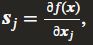 where f(x) is the prediction function of the network and 𝒙j denotes the input vector.

The gradient captures exactly how sensitive the target class score is to changes in the token embeddings at that specific stage of information accumulation.

an attribution score for every single dimension of every token embedding. To translate this back to human-readable token importance, you collapse the embedding dimension. Typically, you sum or compute the L2 norm of the dimensions for each token to yield a single scalar value per token.

This section implements Integrated Gradients (IG), an axiomatic feature attribution method designed to explain the predictions of deep neural networks. We leverage IG specifically to debug the misclassifications identified in our confusion matrix (e.g., why 1997–1999 HTML payloads are leaking into the 2003–2006 bucket).

## 1. Importing the models
### 1.1. About the models
#### Hardware
The model was run locally on the device Dell Precision 3660 (I9 / 64Gig RAM / 4 tb SSD total / Nvidia RTX A4000 16Gig RAM) in the KB Datalab. At the moment of running the experiments, all memory was allocated to the vm hosting the script and data. Additionally, a swap file of around 130 MiB was created for extra computational support.

#### Training experiments
A table of all ~6 experiments with RoBERTa-base can be found in the paper. The experiments with the model's best performance stem from version 1, with a disputable macro f1 score of 91% and average of 94% in experiment v.1.5. After this 'loathing' success, several preprocessing strategies were applied to reduce overfitting, leakage and to cover for the model's overall trustworthiness. 

In this notebook, we will inspect two versions v.2.3 (best performing) and v.2.4. Version 2.2. was briefly inspected using SHAP-values [image below] and immediately pointed towards a leakage problem: the highest shap-values circled around the generator tag, precisely what constitutes the ground truth and thus label attribution. 

Therefore, from v.2.3 on, the same strings used for regular expressions in the labeling functions were removed or _masked_ from the payloads to resolve leakage. Subsequently, these results were shortly analyzed for their Integrated Gradients to explore important tokens pushing or pulling toward the prediction of the correctly predicted label, as we will do below. The tokens pulling the model toward a correct prediction were often natural language, which doesn't come as a surprise since RoBERTa is pretrained on contemporary BookCorpus and web data. However, since we're intestered in particularly the occurrences of tags and structure in website, version 2.4 runs on the 'train_w23' dataset, consisting of _skeletonized_ payloads. The skeletonization entails removing all contents between markup (<> </>), a.k.a. natural language. 

#### Hyperparameters
All versions mentioned in this notebook share most hyperparameters (table ...). For more information on the design choices, please refer to the paper where all decisions are accounted for. Below is listed which method or hyperparameter is incrementally added with each experiment:
- v.2.2: train_w13 dataset (pre-truncated to :1000 characters) 
- v.2.3: train_w13 dataset (pre-truncated) | masking of signals
- v.2.4: train_w23 dataset (whole payloads) | (fast-)masking of signals | skeletonization

In [2]:
# Necessary imports only once
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers_interpret import SequenceClassificationExplainer
import pandas as pd
from sklearn.preprocessing import LabelEncoder

C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 Version 2.3
Loading the model and running the predictions. This might take a while. Try to run this only once.

In [55]:
# Here we will start by loading the model and predictions of experiment v.2.3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_v2_3_name = "C:/Users/anouk.xs4all/Projects/XS4ALL/saved_models/v2_3_optimal_weights_fold1"
model_v2_3 = AutoModelForSequenceClassification.from_pretrained(model_v2_3_name)
model_v2_3.eval()

tokenizer_v2_3 = AutoTokenizer.from_pretrained("roberta-base")

# Make sure to use the correct dataset for each model
df_13 = pd.read_json(r"C:\Users\anouk.xs4all\Projects\XS4ALL\training\train_w13.jsonl", lines=True)

label_encoder = LabelEncoder()
df_13['label'] = label_encoder.fit_transform(df_13['period_bucket'])

# Run the predictions
predictions = []
print("Running predictions")

with torch.no_grad():
    for idx, row in df_13.iterrows():
        # Tokenize de payload
        inputs = tokenizer_v2_3(row['payload'], max_length=512, truncation=True, return_tensors="pt").to(device)
        
        # Forward pass
        outputs = model_v2_3(**inputs)
        
        # Take highest score
        pred_class = torch.argmax(outputs.logits, dim=1).item()
        predictions.append(pred_class)

# Add new predictions
df_13['pred_label'] = predictions

print("Finished")

display(df_13[['period_bucket', 'label', 'pred_label']].head(10))

Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 4265.35it/s]


Running predictions
Finished


,period_bucket,label,pred_label
0,19971999,0,0
1,20002002,1,1
2,20002002,1,2
3,19971999,0,2
4,19971999,0,2
5,19971999,0,0
6,20002002,1,1
7,20032006,2,1
8,19971999,0,2
9,20002002,1,2


#### 1.2.1 Metrics
- Dataset: train_w13
- Best performing fold: 1
- Improvement of validation loss until epoch: 5 <br>

Train loss: 1.0685 | accuracy: 0.6425 <br>
Test loss: 1.0896 | accuracy: 0.6316 <br>

Fold 1 macro F1: 0.553<br>
Mean macro F1: 0.500 <br>
Standard deviation: ± 0.072 <br>

              precision    recall  f1-score   support

    19971999       0.85      0.55      0.67        91
    20002002       0.79      0.74      0.77        94
    20032006       0.33      0.48      0.39        25
    20072010       0.27      0.67      0.39        18

    accuracy                           0.63       228
    macro avg      0.56      0.61      0.55       228
    weighted avg   0.72      0.63      0.66       228
    
    Standard accuracy: 0.632
    Windowed accuracy (+-1): 0.829

## 1.3 Version 2.4
- Dataset: train_23
- Best performing fold: 2
- Lowering validation loss until epoch: 5

In [4]:
# Here we will start by loading the model of experiment v.2.4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_v2_4_name = "C:/Users/anouk.xs4all/Projects/XS4ALL/saved_models/v2_4_optimal_weights_fold2"
model_v2_4 = AutoModelForSequenceClassification.from_pretrained(model_v2_4_name)
model_v2_4.eval()

tokenizer_v2_4 = AutoTokenizer.from_pretrained("roberta-base")

# Make sure to use the correct dataset for each model
df_23 = pd.read_json(r"C:\Users\anouk.xs4all\Projects\XS4ALL\training\train_w23.jsonl", lines=True)

label_encoder = LabelEncoder()
df_23['label'] = label_encoder.fit_transform(df_23['period_bucket'])

# Run the predictions
predictions = []
print("Running predictions")

with torch.no_grad():
    for idx, row in df_23.iterrows():
        # Tokenize de payload
        inputs = tokenizer_v2_4(row['payload'], max_length=512, truncation=True, return_tensors="pt").to(device)
        
        # Forward pass
        outputs = model_v2_4(**inputs)
        
        # Take highest score
        pred_class = torch.argmax(outputs.logits, dim=1).item()
        predictions.append(pred_class)

# Add new predictions
df_23['pred_label'] = predictions

print("Finished")

display(df_23[['period_bucket', 'label', 'pred_label']].head(10))

Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 3114.40it/s]


Running predictions
Finished


,period_bucket,label,pred_label
0,20002002,1,1
1,19971999,0,0
2,20032006,2,0
3,19971999,0,2
4,19971999,0,0
5,20002002,1,0
6,20002002,1,1
7,19971999,0,2
8,20002002,1,1
9,19971999,0,0


#### 1.3.1 Metrics

- Dataset: train_w23
- Best performing fold: 2
- Improvement of validation loss until epoch: 5 <br>

Train loss: 1.1705 | accuracy: 0.4592 <br>
Test loss: 1.2614 | accuracy: 0.5939 <br>

Fold 1 macro F1: 0.490<br>
Mean macro F1: - <br>
Standard deviation: ± 0.102 <br>

              precision    recall  f1-score   support

    19971999       0.83      0.61      0.70       124
    20002002       0.71      0.64      0.67        94
    20032006       0.23      0.28      0.25        25
    20072010       0.22      0.67      0.33        18

    accuracy                           0.59       261
    macro avg      0.50      0.55      0.49       261
    weighted avg   0.68      0.59      0.62       261

    Standard accuracy: 0.594
    Windowed accuracy (+-1): 0.743

#### 1.3.2 Confusion matrix


## 2. Macro-horizontal analysis of v2.3 and v.2.4
The top 5 macro positive and negative tokens for all classes across the versions. **'What did the model learn to associate the website with each era?'**

In [26]:
# Creating the cls explainer for the v.2.3 model using the transfomers_interpret library
# cls_explainer_v_2_3 = SequenceClassificationExplainer(model_v2_3, 
#                                                 tokenizer_v2_3)

In [5]:
# This takes a while so let's load them seperately
cls_explainer_v_2_4 = SequenceClassificationExplainer(model_v2_4, 
                                                 tokenizer_v2_4)

### 2.1 Denoising token fragmentation
RoBERTa does not read words or HTML tags as whole entities. 
It uses a tokenizer framework called BPE (Byte-Pair Encoding). 
BPE chops text into sub-word fragments based on character frequency.
Because of this, we get many numerical tokens, and tags split into multiple tokens.

Here we will merge those BPE chops and remove the 'noise' tokens so that they don't float the scores.

In [6]:
import re
import string

noise_tokens = {
    # RoBERTa special tokens
    '<s>', '</s>', '<pad>', '<unk>', '<mask>',
    # All kinds of single letters, punctuation, whitespaces 
    *list(string.printable)
}

def is_noise_token(token):
    # Remove special RoBERTa prefix
    clean = token.replace('Ġ', '').replace('Ċ', '').strip()
    
    # Filter empty, single chars, pure numbers, pure punctuation
    if not clean:
        return True
    if clean in noise_tokens:
        return True
    if re.match(r'^\d+$', clean):  # also larger numbers like 88, 59
        return True
    if len(clean) <= 1:
        return True

    return False

def merge_bpe_attributions(tokens, attributions):
    merged_tokens, merged_attrs = [], []
    current_token, current_attrs = "", []
    
    for token, attr in zip(tokens, attributions):
        # Ġ marks a word start, < usually marks the start of a new HTML bracket element
        if token.startswith('Ġ') or token.startswith('<'):
            if current_token:
                merged_tokens.append(current_token)
                merged_attrs.append(np.mean(current_attrs))
            current_token = token.replace('Ġ', '')
            current_attrs = [attr]
        else:
            current_token += token
            current_attrs.append(attr)
            
    if current_token:
        merged_tokens.append(current_token)
        merged_attrs.append(np.mean(current_attrs))
        
    return merged_tokens, merged_attrs

In [7]:
# After a few test runs some generators still showed,  but that is probably due to varying notations of e.g. 'FrontPage.Editor'

import sys
sys.path.append("C:/Users/anouk.xs4all/Projects/XS4ALL/script")
from labeling_function_v7 import SignalExtractor

# Hard-coding the masking, already defined in the model algorithm but just to be sure.
def mask_payload(payload):
    if not isinstance(payload, str):
        return ""

    for signal_name, pattern in SignalExtractor.regex_patterns.items():
        payload = pattern.sub("", payload)
    return payload

In [90]:
# test_string = "<!DOCTYPE HTML PUBLIC \"-//W3C//DTD HTML 4.01 Transitional//EN\"><html><body><center>Test for a website from 1997_1999.</center></body></html>"
# print(mask_payload(test_string))

### 2.2 Macro-analysis function

In [11]:
from collections import defaultdict
import pandas as pd
from transformers_interpret import SequenceClassificationExplainer
from tqdm import tqdm

def marco_analysis_table(model, tokenizer, df, label_encoder, num_samples=30):
    """
    Runs the macro-analysis of the Integrated Gradients for the True Positives of the specified model.
    Returns a table of top 10 tokens pushing the true prediction.
    """
    # Apply the cls_explainer function from transformers_interpret library for the specific model and tokenizer defined above
    cls_explainer = SequenceClassificationExplainer(model, tokenizer)
    master_summary_list = []

    for class_idx, class_label in enumerate(tqdm(label_encoder.classes_, desc="Outer loop", position=0)):
        class_name = str(int(class_label))
        print(f" Processing True positives for: {class_name}")
        
        # Filter true positives from thpredictions
        true_positives = df[(df['label'] == class_idx) & (df['pred_label'] == class_idx)]
        
        # Only sample size because we're running this on cpu
        sample_size = min(num_samples, len(true_positives))
        if sample_size == 0:
            print(f"    No true positives for {class_name}. Skipping it.")
            continue
            
        sample_df = true_positives.sample(n=sample_size, random_state=42)
        sample_df['payload'] = sample_df['payload'].apply(mask_payload)
        
        token_total_scores = defaultdict(float)
        token_frequencies = defaultdict(int)
        
        for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc=f"Analyzing {class_name}", position=1, leave=False):
            try:
                # Running each website inside the sample dataset through the model 50 times (think of: k/m)
                # Calculates the gradients along the way to see the characters that cause the model's output score to improve
                raw_attributions = cls_explainer(row['payload'], class_name=class_name)
                # They're called raw here because we will remove the 'noise' with BPE and noise functions
                raw_tokens = [t for t, s in raw_attributions]
                raw_scores = [s for t, s in raw_attributions]
                
                # Apply the BPE fragmentation noise filter for the tokens and scores
                merged_tokens, merged_scores = merge_bpe_attributions(raw_tokens, raw_scores)
                
                # Filter noise and count frequencies
                for token, score in zip(merged_tokens, merged_scores):
                    if not is_noise_token(token):
                        clean_token = token.strip()
                        token_total_scores[clean_token] += score
                        token_frequencies[clean_token] += 1
            except Exception:
                continue
                
        # Calculate the average score per unique token
        macro_records = []
        for token, total_score in token_total_scores.items():
            freq = token_frequencies[token]
            if freq >= 1:  # Must appear in at least 2 different documents
                macro_records.append({
                    'Token': token,
                    'Macro_Score': total_score / freq,
                    'Class': class_name
                })
                
        if macro_records:
            macro_df = pd.DataFrame(macro_records)
            macro_df.to_csv(f'./output/full_macro_scores_{class_name}.csv', index=False)
            top_pos = macro_df.sort_values(by='Macro_Score', ascending=False).head(10).copy()
            master_summary_list.append(top_pos)
            
    if not master_summary_list:
        print("[Error] Found no data to generate the dataset.")
        return None
        
    # Stack the results into one dataframe
    final_table = pd.concat(master_summary_list, ignore_index=True)
    
    # For a horizontal comparison, we can flip the Class values to become heades. .cumcount() groups the data by period and counts them
    # top token for 1997 e.g. is row_num = 0
    final_table['row_num'] = final_table.groupby('Class').cumcount()
    
    # Take the token assigned to row 0 for 1997, and place it in the '1997' column on row 0.
    pivot_table = final_table.pivot(index='row_num', columns='Class', values='Token')
    
    # Give an incrementing index number for clear representation of tokens
    pivot_table.index = range(1, len(pivot_table) + 1)
    pivot_table.columns.name = None
    
    return pivot_table

#### 2.2.1 Version 2.3 Macro-analysis

Small subset test of 4 samples

In [88]:
print("=== START MACRO-ANALYSIS MODEL V2.3 ===")
table_v2_3 = marco_analysis_table(
    model=model_v2_3, 
    tokenizer=tokenizer_v2_3, 
    df=df_13, 
    label_encoder=label_encoder,
    num_samples=4
)

display(table_v2_3)

=== START MACRO-ANALYSIS MODEL V2.3 ===
 Processing True positives for: 19971999
 Processing True positives for: 20002002


C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers_interpret\explainers\text\sequence_classification.py:220: UserWarning: '20002002' is not found in self.label2id keys.Defaulting to predicted index instead.
  warnings.warn(s)


 Processing True positives for: 20032006


C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers_interpret\explainers\text\sequence_classification.py:220: UserWarning: '20032006' is not found in self.label2id keys.Defaulting to predicted index instead.
  warnings.warn(s)


 Processing True positives for: 20072010


C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers_interpret\explainers\text\sequence_classification.py:220: UserWarning: '20072010' is not found in self.label2id keys.Defaulting to predicted index instead.
  warnings.warn(s)


,19971999,20002002,20032006,20072010
1,"<metaname=""ProgId""content=""FrontPage.Editor.Do...","<metahttp-equiv=""Content-Type""content=""text/ht...",<style>Ċv\:*{behavior:url(#default#VML)}Ċo\:*{...,</title>Ċ
2,<HEAD>Ċ,</title>Ċ,"<metaname=""ProgId""content=""FrontPage.Editor.Do...",<tr>
3,<HTML>Ċ,<html>Ċ,"<htmlxmlns:v=""urn:schemas-microsoft-com:vml""xm...","<divalign=""center"">"
4,</head>,<head>Ċ,</title>Ċ,<![endif]-->Ċ
5,<BR><BR>Ċ,<title>HomepageErikSchute,</head>,NaN
6,<head>Ċ,</frameset>Ċ,</style>Ċ,NaN
7,"<metahttp-equiv=""Content-Type""content=""text/ht...",</head>,<html>,NaN
8,</A>Ċ,<center>,<head>Ċ,NaN
9,<html>,<td>,<!--[if!mso]>Ċ,NaN
10,NaN,<tr>,"<metahttp-equiv=""Content-Type""content=""text/ht...",NaN


In [94]:
# Save results to a csv
# csv_v2_3 = pd.DataFrame(table_v2_3)
# csv_v2_3.to_csv('macro_top10tokens_v2_3.csv')

In [107]:
print("=== START MACRO-ANALYSIS MODEL V2.3 ===")
table_v2_3 = marco_analysis_table(
    model=model_v2_3, 
    tokenizer=tokenizer_v2_3, 
    df=df_13, 
    label_encoder=label_encoder,
    num_samples=50
)

display(table_v2_3)

=== START MACRO-ANALYSIS MODEL V2.3 ===


Outer loop:   0%|                                                                                | 0/4 [00:00<?, ?it/s]

 Processing True positives for: 19971999



Analyzing 19971999:   8%|█████                                                          | 4/50 [03:16<37:20, 48.70s/it]Exception ignored in: <function tqdm.__del__ at 0x000001E264849120>
Traceback (most recent call last):
  File "C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'

Outer loop:  25%|█████████████████                                                   | 1/4 [40:05<2:00:17, 2405.85s/it]

 Processing True positives for: 20002002


...

 Processing True positives for: 20032006



Analyzing 20032006:   0%|                                                                       | 0/50 [00:00<?, ?it/s]C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers_interpret\explainers\text\sequence_classification.py:220: UserWarning: '20032006' is not found in self.label2id keys.Defaulting to predicted index instead.
  warnings.warn(s)

Outer loop:  75%|███████████████████████████████████████████████████                 | 3/4 [2:06:07<43:13, 2593.91s/it]

 Processing True positives for: 20072010



Analyzing 20072010:   0%|                                                                       | 0/50 [00:00<?, ?it/s]C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers_interpret\explainers\text\sequence_classification.py:220: UserWarning: '20072010' is not found in self.label2id keys.Defaulting to predicted index instead.
  warnings.warn(s)

Outer loop: 100%|████████████████████████████████████████████████████████████████████| 4/4 [2:53:41<00:00, 2605.31s/it]


,19971999,20002002,20032006,20072010
1,</SCRIPT>Ċ,"<htmlxmlns=""http://www.w3.org/1999/xhtml"">Ċ",</TITLE>,"<metaname=""viewport""content=""width=device-widt..."
2,<HEAD>,"<metahttp-equiv=""Content-Type""content=""text/ht...",</script>Ċ,"<metaname=""viewport""content=""width=device-widt..."
3,<CENTER>Ċ,"<metahttp-equiv=""content-type""content=""text/ht...",<tr>Ċ,"<metaname=""viewport""content=""width=device-widt..."
4,</TITLE>,"<metahttp-equiv=""Content-Type""content=""text/ht...","<htmlxmlns:v=""urn:schemas-microsoft-com:vml""Ċx...","<metaname=""viewport""content=""width=device-widt..."
5,</TITLE></HEAD>Ċ,"<metahttp-equiv=""content-type""content=""text/ht...",</head>Ċ,</div>Ċ
6,"<metaname=""ProgId""content=""FrontPage.Editor.Do...","<styletype=""text/css"">Ċ",<style>Ċv\:*{behavior:url(#default#VML)}Ċo\:*{...,"<metaname=""ProgId""content=""FrontPage.Editor.Do..."
7,"<SCRIPTLANGUAGE=""JavaScript"">varjavascript_ver...",<HTML>Ċ,"<metaname=""ProgId""content=""FrontPage.Editor.Do...","<metacharset=""utf-8""/>"
8,</TITLE>Ċ,"<scriptlanguage=""JavaScript""type=""text/JavaScr...","<p>Thispageusesframes,butyourbrowserdoesn'tsup...",<body>Ċ
9,<HEAD>Ċ,</title>Ċ,<HTML>,</h2>
10,</BODY>Ċ,<head>Ċ,"<BODYBGCOLOR=""#FFFFFF""TEXT=""#000000"">Ċ","<htmllang=""nl"">"


In [110]:
# Save results to csv
csv_v2_3_1 = pd.DataFrame(table_v2_3)
csv_v2_3_1.to_csv('macro_top10tokens_v2_3_1.csv')

#### 2.2.2. Version 2.4 Macor-analysis

In [14]:
def emergency_macro_analysis(model, tokenizer, df, label_encoder, num_samples=5):
    # 1. Lock the model and explicitly feed it your labels so the explainer doesn't get confused
    model.eval()
    model.config.id2label = {0: "1997-1999", 1: "2000-2002", 2: "2003-2006", 3: "2007-2010"}
    
    cls_explainer = SequenceClassificationExplainer(model, tokenizer)
    master_summary_list = []

    for class_idx, class_label in enumerate(tqdm(label_encoder.classes_, desc="Outer loop", position=0)):
        # Grab the actual string name (e.g., "1997-1999")
        class_name_str = model.config.id2label[class_idx]
        print(f"\nProcessing True positives for: {class_name_str}")
        
        true_positives = df[(df['label'] == class_idx) & (df['pred_label'] == class_idx)]
        sample_size = min(num_samples, len(true_positives))
        
        if sample_size == 0:
            continue
            
        sample_df = true_positives.sample(n=sample_size, random_state=42)
        token_total_scores = defaultdict(float)
        
        for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc=f"Analyzing {class_name_str}", leave=False):
            try:
                # Truncate to 256 tokens to guarantee it fits in memory
                raw_payload = mask_payload(row['payload'])
                strict_tokens = tokenizer(raw_payload, truncation=True, max_length=256, return_tensors="pt")
                short_text = tokenizer.decode(strict_tokens['input_ids'][0], skip_special_tokens=True)

                # Run explainer with the exact string name
                raw_attributions = cls_explainer(short_text, class_name=class_name_str)
                
                # We are bypassing the BPE merge and noise filters to GUARANTEE data extraction.
                # We simply remove the BERT special tags.
                for token, score in raw_attributions:
                    if token not in ['<s>', '</s>', '<pad>', '[CLS]', '[SEP]']: 
                        clean_token = token.replace('Ġ', '').strip() # Clean RoBERTa's weird 'Ġ' spaces
                        if len(clean_token) > 1: # Skip single punctuation marks
                            token_total_scores[clean_token] += score
                            
            except Exception as e:
                continue
                
        # 2. BRUTE FORCE EXPORT: No frequency checks. If it has a score, we keep it.
        macro_records = []
        for token, total_score in token_total_scores.items():
            macro_records.append({
                'Token': token,
                'Macro_Score': total_score,
                'Class': class_name_str
            })
                
        if macro_records:
            macro_df = pd.DataFrame(macro_records)
            
            # Sort by highest score and grab the top 15 
            top_pos = macro_df.sort_values(by='Macro_Score', ascending=False).head(15).copy()
            master_summary_list.append(top_pos)

    if not master_summary_list:
        print("[CRITICAL ERROR] The model generated absolutely zero attributions.")
        return None
        
    # Assemble the final table
    final_table = pd.concat(master_summary_list, ignore_index=True)
    final_table['row_num'] = final_table.groupby('Class').cumcount()
    pivot_table = final_table.pivot(index='row_num', columns='Class', values='Token')
    pivot_table.index = range(1, len(pivot_table) + 1)
    pivot_table.columns.name = None
    
    return pivot_table

# RUN IT:
# my_final_table = emergency_macro_analysis(model_v2_4, tokenizer_v2_4, df_13, label_encoder)
# display(my_final_table)

In [17]:
print("=== START MACRO-ANALYSIS MODEL V2.4 ===")
table_v2_4 = emergency_macro_analysis(
    model=model_v2_4, 
    tokenizer=tokenizer_v2_4, 
    df=df_23, 
    label_encoder=label_encoder,
    num_samples=5
)

display(table_v2_4)

=== START MACRO-ANALYSIS MODEL V2.4 ===


Outer loop:   0%|                                                                                | 0/4 [00:00<?, ?it/s]


Processing True positives for: 1997-1999



Analyzing 1997-1999:   0%|                                                                       | 0/5 [00:00<?, ?it/s]C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers_interpret\explainers\text\sequence_classification.py:220: UserWarning: '1997-1999' is not found in self.label2id keys.Defaulting to predicted index instead.
  warnings.warn(s)

Outer loop:  25%|█████████████████▊                                                     | 1/4 [02:14<06:42, 134.20s/it]


Processing True positives for: 2000-2002


...


Processing True positives for: 2003-2006



Analyzing 2003-2006:   0%|                                                                       | 0/4 [00:00<?, ?it/s]C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers_interpret\explainers\text\sequence_classification.py:220: UserWarning: '2003-2006' is not found in self.label2id keys.Defaulting to predicted index instead.
  warnings.warn(s)

Outer loop:  75%|█████████████████████████████████████████████████████▎                 | 3/4 [06:59<02:17, 137.18s/it]


Processing True positives for: 2007-2010



Analyzing 2007-2010:   0%|                                                                       | 0/5 [00:00<?, ?it/s]C:\Users\anouk.xs4all\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers_interpret\explainers\text\sequence_classification.py:220: UserWarning: '2007-2010' is not found in self.label2id keys.Defaulting to predicted index instead.
  warnings.warn(s)

Outer loop: 100%|███████████████████████████████████████████████████████████████████████| 4/4 [09:16<00:00, 139.23s/it]


,1997-1999,2000-2002,2003-2006,2007-2010
1,td,"=""","=""",class
2,><,css,Page,"="""
3,></,88,Front,css
4,th,59,Content,width
5,tr,html,stat,icon
6,"=""",org,59,2011
7,"""></",http,"=""#",><
8,"=""/",xml,Editor,http
9,head,content,network,content
10,img,class,DJ,Page
